In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
 pip install -q tensorflow-model-optimization

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 1.7 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from tensorflow_model_optimization.python.core.keras.compat import keras
import tempfile
import zipfile
import os
import tensorflow_model_optimization as tfmot

In [ ]:
batch_size = 64
img_height = 224
img_width = 224

data_dir = "/content/drive/MyDrive/TinyML/Datasets/Tomatoes Diseases/"

In [ ]:
test_ds = keras.utils.image_dataset_from_directory(
    data_dir + "Test",
    validation_split=0.2,
    subset="training",
    seed=48,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
)

Found 3198 files belonging to 10 classes.
Using 2559 files for training.


In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    data_dir + "Train",
    validation_split=0.2,
    subset="training",
    seed=48,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
)

Found 12860 files belonging to 10 classes.
Using 10288 files for training.


In [ ]:
class_names = test_ds.class_names
class_names

['Bacterial_spot',
 'Early_blight',
 'Late_blight',
 'Leaf_Mold',
 'Septoria_leaf_spot',
 'Spider_mite_Two_spotted_sm',
 'Target_Spot',
 'Yellow_Leaf__Curl_Virus',
 'healthy',
 'mosaic_virus']

In [ ]:
test_ds = test_ds.take(16)
train_ds = train_ds.take(125)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

test_nds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)
train_nds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
model_name = "drive/MyDrive/TinyML/SaveModels/AlexNet0.h5"

In [ ]:
def get_gzipped_model_size(file, x):
  # Returns size of gzipped model, in bytes.
  zipped_file = "drive/MyDrive/TinyML/SaveModels/" + x
  with zipfile.ZipFile(zipped_file, 'w', compression=zipfile.ZIP_DEFLATED) as f:
    f.write(file)

  return os.path.getsize(zipped_file) / 1024

In [ ]:
print("Base Model size: ", get_gzipped_model_size(model_name, "AlexNet.zip"), ' KB')

Base Model size:  169325.5849609375  KB


In [ ]:
pruned_alexnet = "drive/MyDrive/TinyML/SaveModels/pruned_AlexNet0.h5"

In [ ]:
print("Pruned AlexNet size: ", get_gzipped_model_size(pruned_alexnet, "pruned_AlexNet.zip"), ' KB')

Pruned AlexNet size:  15432.7373046875  KB


In [ ]:
clustered_alexnet = "drive/MyDrive/TinyML/SaveModels/clustered_AlexNet.h5"


In [ ]:
print("Clustered AlexNet size: ", get_gzipped_model_size(clustered_alexnet, "clustered_AlexNet.zip"), ' KB')

Clustered AlexNet size:  1516.4970703125  KB


In [ ]:
quant_alexnet = keras.models.load_model("drive/MyDrive/TinyML/SaveModels/clustered_AlexNet.h5")

quant_alexnet.compile(
  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  optimizer=keras.optimizers.Adam(learning_rate=1e-5),
  metrics=["accuracy"]
)

quant_alexnet.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d_5 (Conv2D)           (None, 54, 54, 96)        34944     
                                                                 
 batch_normalization_5 (Bat  (None, 54, 54, 96)        384       
 chNormalization)                                                
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 26, 26, 96)        0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 26, 26, 256)       614656    
                                                                 
 batch_normalization_6 (Bat  (None, 26, 26, 256)      

In [ ]:
def representative_data_gen():
  for image, label in train_nds.take(5):
    for img  in image:
      image = np.array(img, dtype=np.float32, ndmin=4)
      yield [image]

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(quant_alexnet)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_data_gen

#converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
#converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8, tf.lite.OpsSet.SELECT_TF_OPS]
quant_mobilenet_tflite = converter.convert()

/usr/local/lib/python3.10/dist-packages/tensorflow/lite/python/convert.py:983: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
tflite_name = "drive/MyDrive/TinyML/SaveModels/ptq_AlexNet.tflite"

with open(tflite_name, "wb") as f:
  f.write(quant_mobilenet_tflite)


print("PTQ TFLite AlexNet size:", get_gzipped_model_size(tflite_name, "ptq_AlexNet.zip"), ' KB')

PTQ TFLite AlexNet size: 1154.31640625  KB


In [ ]:
def eval_model(test_ds):
  interpreter = tf.lite.Interpreter(tflite_name)
  interpreter.allocate_tensors()

  input_index = interpreter.get_input_details()[0]["index"]
  output_index = interpreter.get_output_details()[0]["index"]

  prediction_digits = []
  vrai = []
  i = 0
  nbre = 0
  num_correct = 0

  for images, labels in test_ds:

    for img, lab in zip(images, labels):
      if i%100 == 0:
        print(f"Evaluated on {i} results so far.")
      i += 1

      img = np.expand_dims(img, axis=0).astype(np.float32)
      #img = (np.expand_dims(img, axis=0) * 255).astype(np.int8)
      interpreter.set_tensor(input_index, img)

      interpreter.invoke()

      output = interpreter.get_tensor(output_index)
      digit = np.argmax(output)
      prediction_digits.append(digit)


      vrai.append(lab)

      if digit == lab:
        num_correct += 1

  prediction_digits = np.array(prediction_digits)

  return num_correct, prediction_digits, vrai

In [ ]:
n, predict, lab = eval_model(test_nds)

Evaluated on 0 results so far.
Evaluated on 100 results so far.
Evaluated on 200 results so far.
Evaluated on 300 results so far.
Evaluated on 400 results so far.
Evaluated on 500 results so far.
Evaluated on 600 results so far.
Evaluated on 700 results so far.
Evaluated on 800 results so far.
Evaluated on 900 results so far.
Evaluated on 1000 results so far.


In [ ]:
print(f"{n}/{1024}\n")

954/1024



In [ ]:
confusion_matrix(y_true=lab,
                 y_pred=predict)

array([[125,   0,   0,   0,   0,   0,   1,   1,   0,   0],
       [  2,  53,   6,   0,   6,   0,   4,   0,   0,   0],
       [  0,   3, 122,   1,   0,   0,   0,   0,   0,   0],
       [  0,   0,   1,  54,   4,   1,   1,   0,   0,   0],
       [  0,   1,   0,   0, 122,   0,   1,   0,   1,   0],
       [  0,   0,   0,   0,   0,  76,  19,   0,   0,   2],
       [  0,   0,   0,   0,   1,   1,  98,   0,   0,   0],
       [  3,   1,   0,   1,   0,   2,   0, 182,   0,   0],
       [  3,   0,   0,   0,   0,   0,   0,   0,  99,   0],
       [  0,   0,   0,   0,   3,   0,   0,   0,   0,  23]])

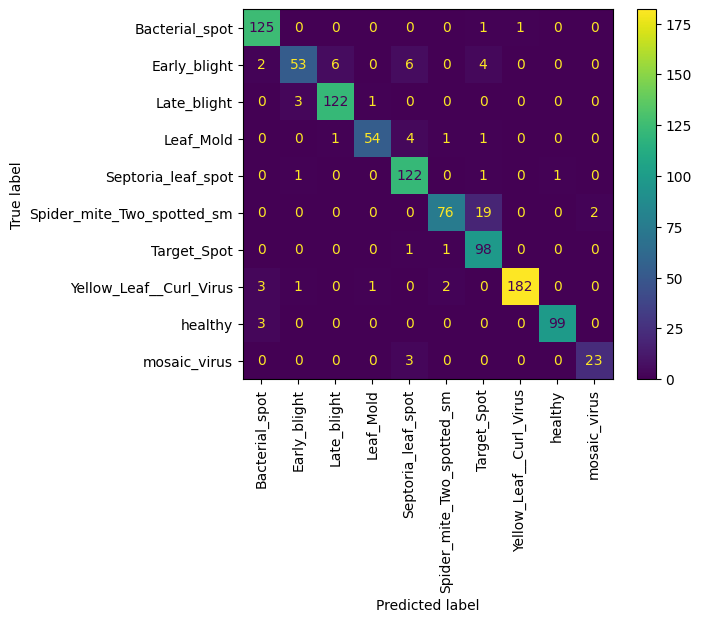

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    lab, predict, display_labels=class_names, xticks_rotation='vertical'
)

In [ ]:
precision = precision_score(lab, predict, average='macro')
recall = recall_score(lab, predict, average='macro')
f1 = f1_score(lab, predict, average='macro')

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
#print("Accuracy", acc)
#print("Loss", loss)

Precision: 0.9305581799202924
Recall: 0.9141902449148327
F1 Score: 0.9192459946371667
